<a href="https://colab.research.google.com/github/cu24250171/cu24250171-Divya-B.-Tech-CSE-A-3rd-year---Computer-Vision-labsheets/blob/main/LABSHEET_4_COMPUTER_VISION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAME - DIVYA

B.TECH CSE 'A' 3RD YEAR

CU24250171

ROLL NO.17


1. Build a tool that computes and visualizes the 2D Fourier sepctrum (magnitude and phase) of an image.

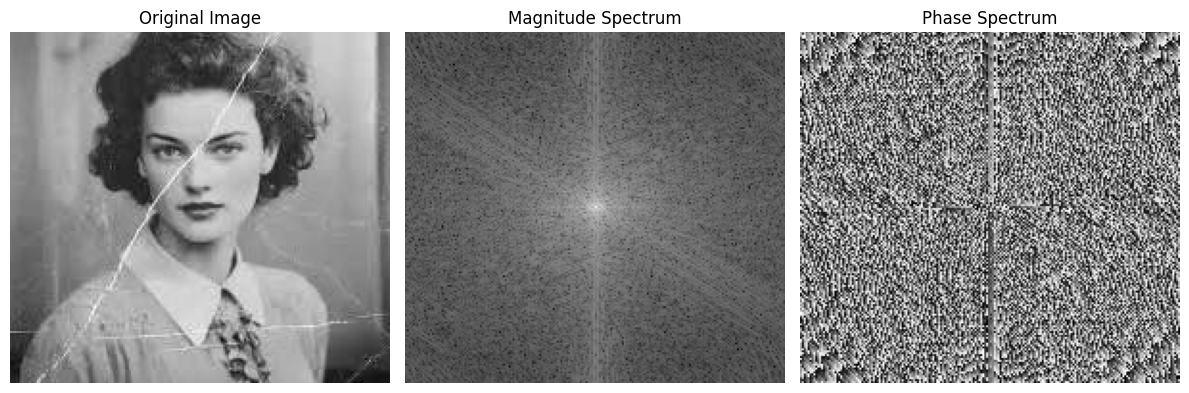

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
image = cv2.imread("/content/image.jpg",cv2.IMREAD_GRAYSCALE)
if image is None:
  print("Error: Image not found!")
  exit()
f = np.fft.fft2(image)
fshift = np.fft.fftshift(f)
magnitude = np.abs(fshift)
magnitude_spectrum = np.log(1 + magnitude)
phase_spectrum = np.angle(fshift)
plt.figure(figsize=(12,8))
plt.subplot(1,3,1)
plt.imshow(image,cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.subplot(1,3,2)
plt.imshow(magnitude_spectrum,cmap='gray')
plt.title("Magnitude Spectrum")
plt.axis("off")
plt.subplot(1,3,3)
plt.imshow(phase_spectrum,cmap='gray')
plt.title("Phase Spectrum")
plt.axis("off")
plt.tight_layout()
plt.show()

2. Develop a frequency-domain low-pass filter (ideal,Butterworth, and Gaussian) and compare the resulting blur effects.

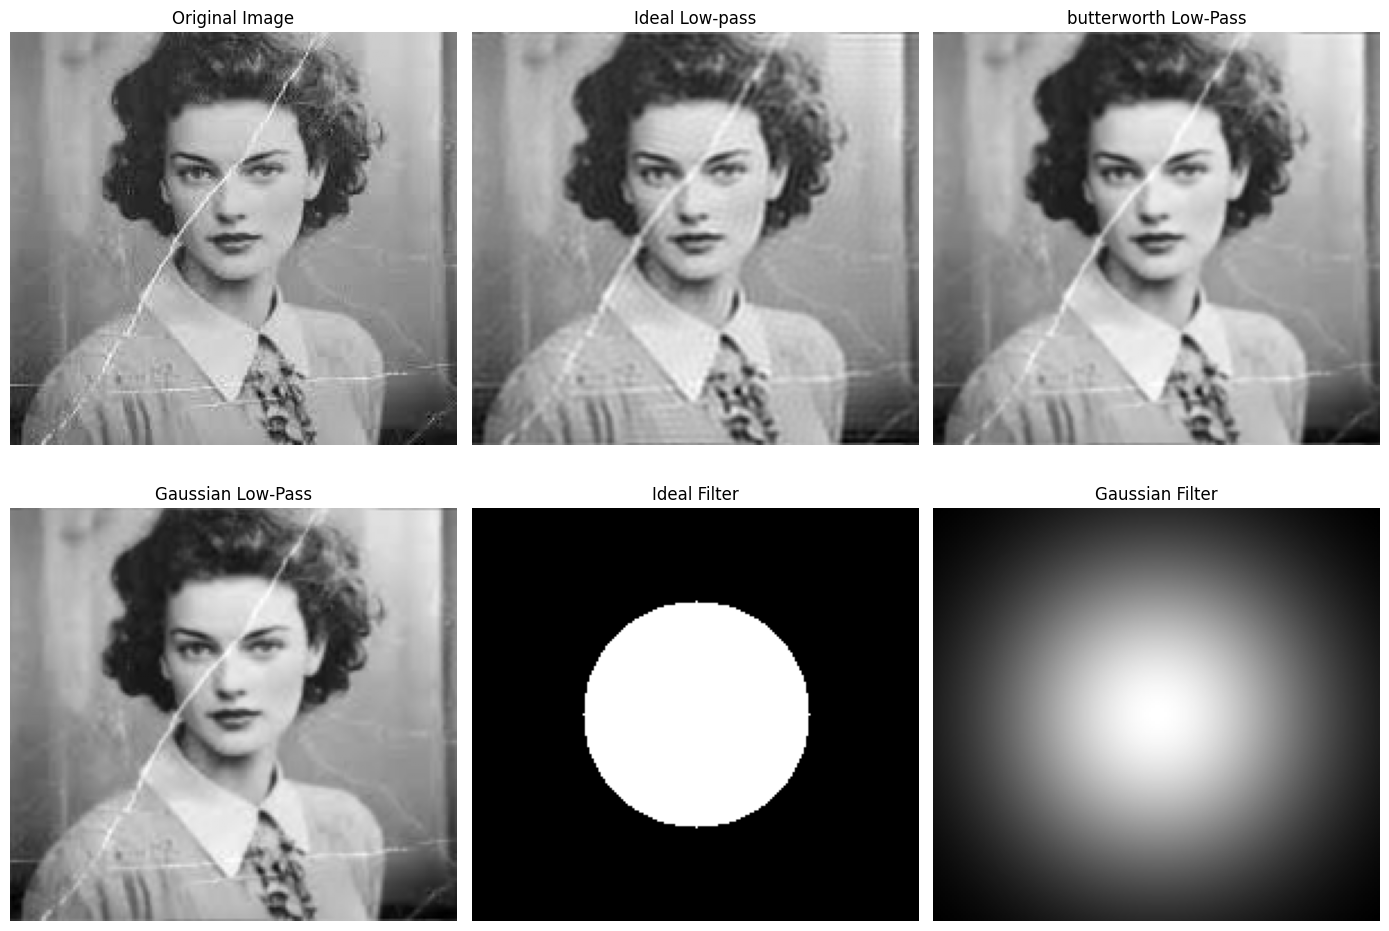

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
image = cv2.imread('/content/image.jpg',cv2.IMREAD_GRAYSCALE)
if image is None:
  print("Error: Image not found!")
  exit()
f = np.fft.fft2(image)
fshift = np.fft.fftshift(f)
rows, cols = image.shape
crow, ccol = rows // 2, cols // 2
y,x = np.ogrid[:rows,:cols]
D = np.sqrt((x - ccol)**2 + (y - crow)**2)
D0 = 50
ideal_filter = np.zeros((rows,cols))
ideal_filter[D <= D0] = 1
n = 2
butterworth_filter = 1 / (1 + (D / D0)**(2 * n))
gaussian_filter = np.exp(-(D**2) / (2 * D0**2))
ideal_result = fshift * ideal_filter
butterworth_result = fshift * butterworth_filter
gaussian_result = fshift * gaussian_filter
ideal_img = np.abs(
    np.fft.ifft2(np.fft.ifftshift(ideal_result))
)
butterworth_img = np.abs(
    np.fft.ifft2(np.fft.ifftshift(butterworth_result))
)
gaussian_img = np.abs(
    np.fft.ifft2(np.fft.ifftshift(gaussian_result))
)
plt.figure(figsize=(14,10))
plt.subplot(2,3,1)
plt.imshow(image,cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.subplot(2,3,2)
plt.imshow(ideal_img,cmap='gray')
plt.title("Ideal Low-pass")
plt.axis("off")
plt.subplot(2,3,3)
plt.imshow(butterworth_img,cmap='gray')
plt.title("butterworth Low-Pass")
plt.axis("off")
plt.subplot(2,3,4)
plt.imshow(gaussian_img,cmap='gray')
plt.title("Gaussian Low-Pass")
plt.axis("off")
plt.subplot(2,3,5)
plt.imshow(ideal_filter,cmap='gray')
plt.title("Ideal Filter")
plt.axis("off")
plt.subplot(2,3,6)
plt.imshow(gaussian_filter,cmap='gray')
plt.title("Gaussian Filter")
plt.axis("off")
plt.tight_layout()
plt.show()


3. Create a frequency-domain high-pass filter to enhance edges, and compare the result with the spatial-domain edge detection.

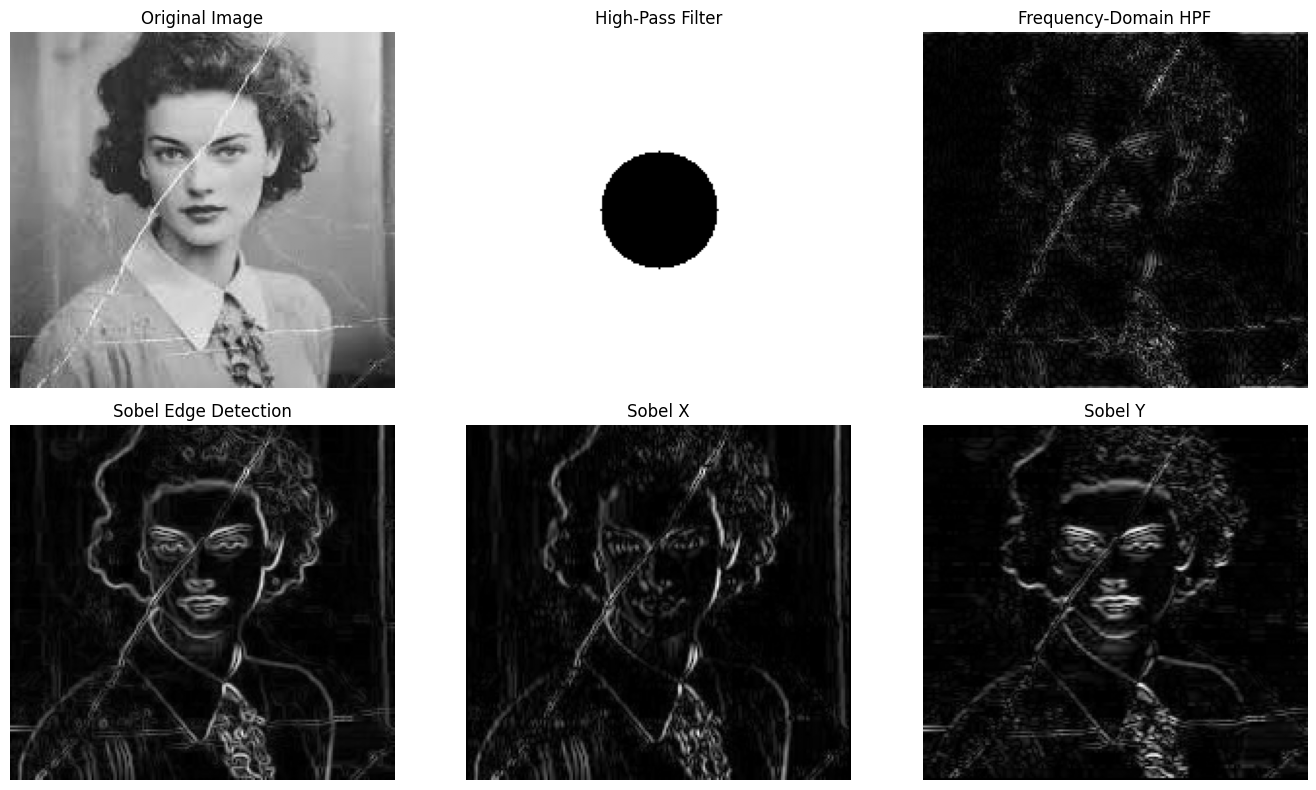

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
image = cv2.imread('/content/image.jpg',cv2.IMREAD_GRAYSCALE)
if image is None:
  print("Error: Image not found!")
  exit()
# frquency domain high-pass filter
f = np.fft.fft2(image)
fshift = np.fft.fftshift(f)
rows,cols = image.shape
crow,ccol = rows // 2, cols // 2
y , x = np.ogrid[:rows,:cols]
D = np.sqrt((x - ccol)**2 + (y-crow)**2)
D0 = 30
high_pass_filter = np.ones((rows,cols))
high_pass_filter[D <= D0] = 0
filtered = fshift * high_pass_filter
high_pass_result = np.abs(np.fft.ifft2(np.fft.ifftshift(filtered)))
high_pass_result = cv2.normalize(high_pass_result,None,0,255,cv2.NORM_MINMAX).astype(np.uint8)
# spatial domain edge detection
sobel_x = cv2.Sobel(image,cv2.CV_64F,1,0,ksize=3)
sobel_y = cv2.Sobel(image,cv2.CV_64F,0,1,ksize=3)
sobel = np.sqrt(sobel_x**2 + sobel_y**2)
sobel = cv2.normalize(sobel,None,0,255,cv2.NORM_MINMAX).astype(np.uint8)
# display results
plt.figure(figsize=(14,8))
plt.subplot(2,3,1)
plt.imshow(image,cmap='gray')
plt.title("Original Image")
plt.axis("Off")
plt.subplot(2, 3, 2)
plt.imshow(high_pass_filter, cmap="gray")
plt.title("High-Pass Filter")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(high_pass_result, cmap="gray")
plt.title("Frequency-Domain HPF")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(sobel, cmap="gray")
plt.title("Sobel Edge Detection")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(np.abs(sobel_x), cmap="gray")
plt.title("Sobel X")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(np.abs(sobel_y), cmap="gray")
plt.title("Sobel Y")
plt.axis("off")
plt.tight_layout()
plt.show()



4. Build a periodic-noise removal tool that identifes and removes noise spikes visible in the frequency spectrum.

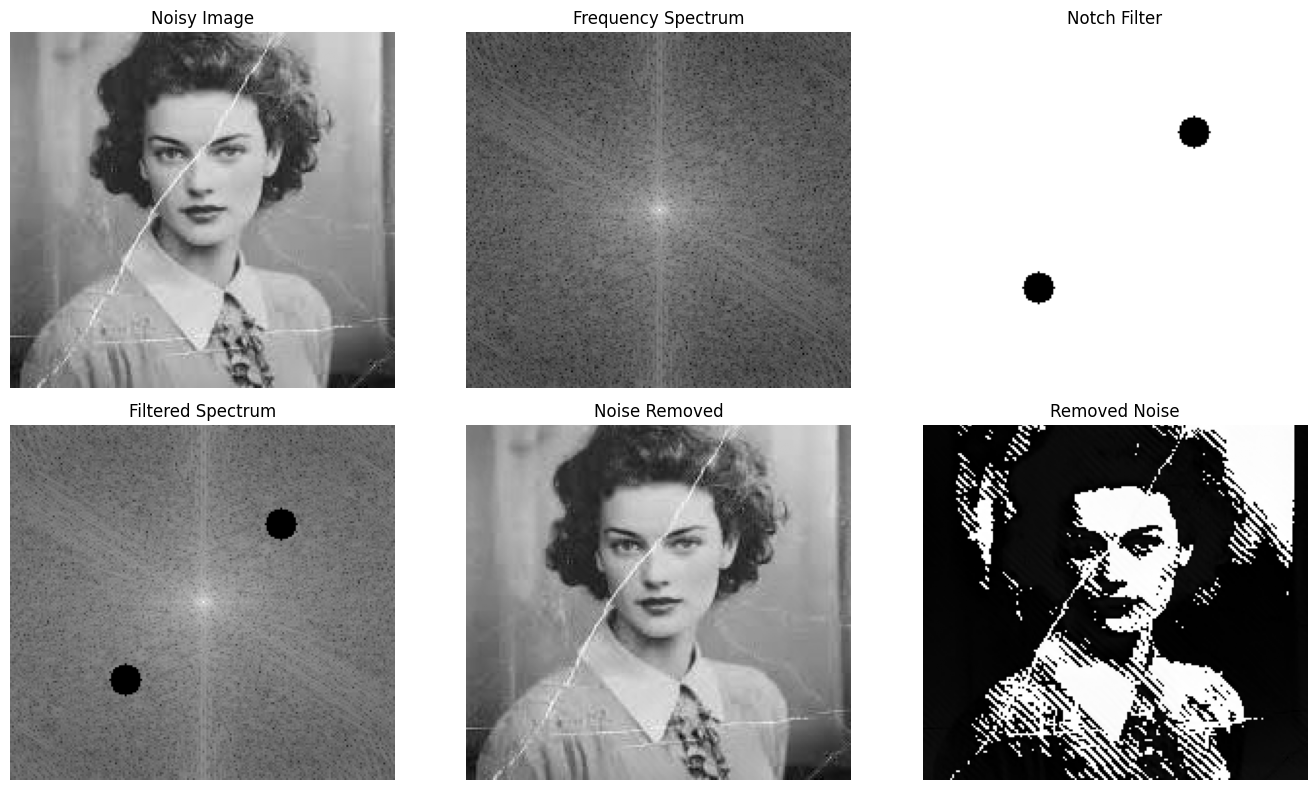

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
image = cv2.imread('/content/image.jpg',cv2.IMREAD_GRAYSCALE)
if image is None:
  print("Error: Image not found!")
  exit()
# fourier Transform
f = np.fft.fft2(image)
fshift = np.fft.fftshift(f)
magnitude = np.log(1 + np.abs(fshift))
# Create notch filter
rows, cols = image.shape
crow,ccol = rows // 2, cols//2
notch_filter = np.ones((rows,cols),np.uint8)
r = 8
spikes = [
    (crow-40,ccol + 40),
    (crow+40,ccol - 40)
]
for y, x in spikes:
  cv2.circle(notch_filter,(x,y),r,0,-1)
  sym_y = 2 * crow - y
  sym_x = 2 * ccol - x
  cv2.circle(notch_filter,(sym_x,sym_y),r,0,-1)
# apply notch filter
filtered = fshift * notch_filter
result = np.fft.ifft2(np.fft.ifftshift(filtered))
result = np.abs(result)
# normalize results
result = cv2.normalize(result,None,0,255,cv2.NORM_MINMAX).astype(np.uint8)
# display results
plt.figure(figsize=(14,8))
plt.subplot(2, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Noisy Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(magnitude, cmap="gray")
plt.title("Frequency Spectrum")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(notch_filter, cmap="gray")
plt.title("Notch Filter")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(np.log(1 + np.abs(filtered)), cmap="gray")
plt.title("Filtered Spectrum")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(result, cmap="gray")
plt.title("Noise Removed")
plt.axis("off")
plt.subplot(2, 3, 6)
plt.imshow(image-result,cmap='gray')
plt.title("Removed Noise")
plt.axis("off")
plt.tight_layout()
plt.show()

5. Develop a program that compresses an image by retaining only the top-k Fourier coefficients and reconstructs it.

Total Fourier coefficients: 36234
coefficients retained: 5000
Compression ratio: 7.25


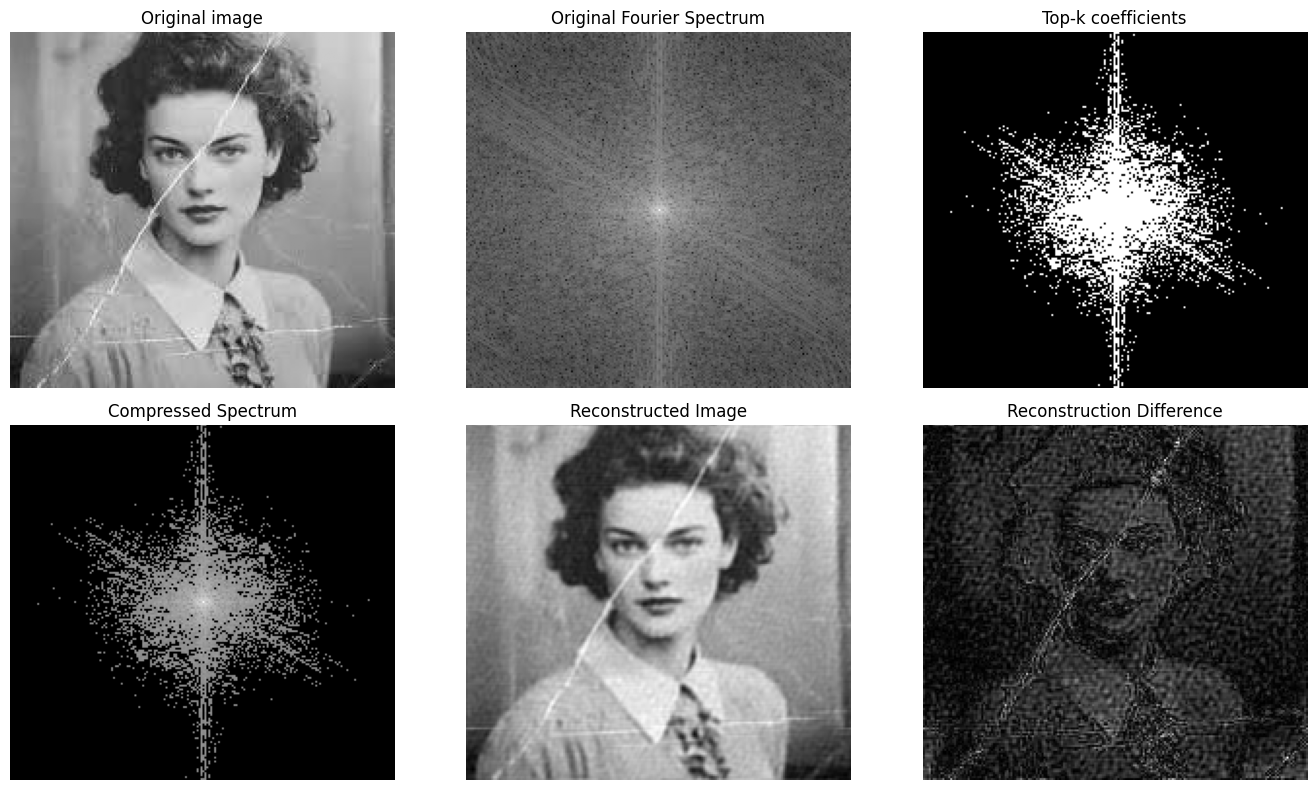

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
image = cv2.imread('/content/image.jpg',cv2.IMREAD_GRAYSCALE)
if image is None:
  print("Error: Image not found!")
  exit()
# fourier Transform
f = np.fft.fft2(image)
fshift = np.fft.fftshift(f)
magnitude = np.abs(fshift)
k = 5000
flat_magnitude = magnitude.flatten()
threshold = np.partition(flat_magnitude,-k)[-k]
mask = magnitude >= threshold
compressed_fshift = fshift * mask
reconstructed = np.fft.ifft2(
    np.fft.ifftshift(compressed_fshift)
)
reconstructed = np.abs(reconstructed)
reconstructed = cv2.normalize(
    reconstructed,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)
total_coefficients = image.shape[0] * image.shape[1]
actual_k = np.count_nonzero(mask)
compression_ratio = total_coefficients / actual_k
print("Total Fourier coefficients:", total_coefficients)
print("coefficients retained:", actual_k)
print("Compression ratio:",round(compression_ratio,2))
plt.figure(figsize=(14,8))
plt.subplot(2,3,1)
plt.imshow(image,cmap='gray')
plt.title("Original image")
plt.axis("off")
plt.subplot(2,3,2)
plt.imshow(
    np.log(1 + magnitude),
    cmap='gray'
)
plt.title("Original Fourier Spectrum")
plt.axis("off")
plt.subplot(2,3,3)
plt.imshow(
    mask,
    cmap='gray'
)
plt.title("Top-k coefficients")
plt.axis("off")
plt.subplot(2,3,4)
plt.imshow(np.log(1 + np.abs(compressed_fshift)),cmap='gray')
plt.title("Compressed Spectrum")
plt.axis("off")
plt.subplot(2,3,5)
plt.imshow(reconstructed,cmap='gray')
plt.title("Reconstructed Image")
plt.axis("off")
plt.subplot(2,3,6)
difference = cv2.absdiff(image,reconstructed)
plt.imshow(difference,cmap='gray')
plt.title("Reconstruction Difference")
plt.axis("off")
plt.tight_layout()
plt.show()


6. Create a watermark hide/reveal tool that embeds and extracts a watermark using frequency-domain manipulation.

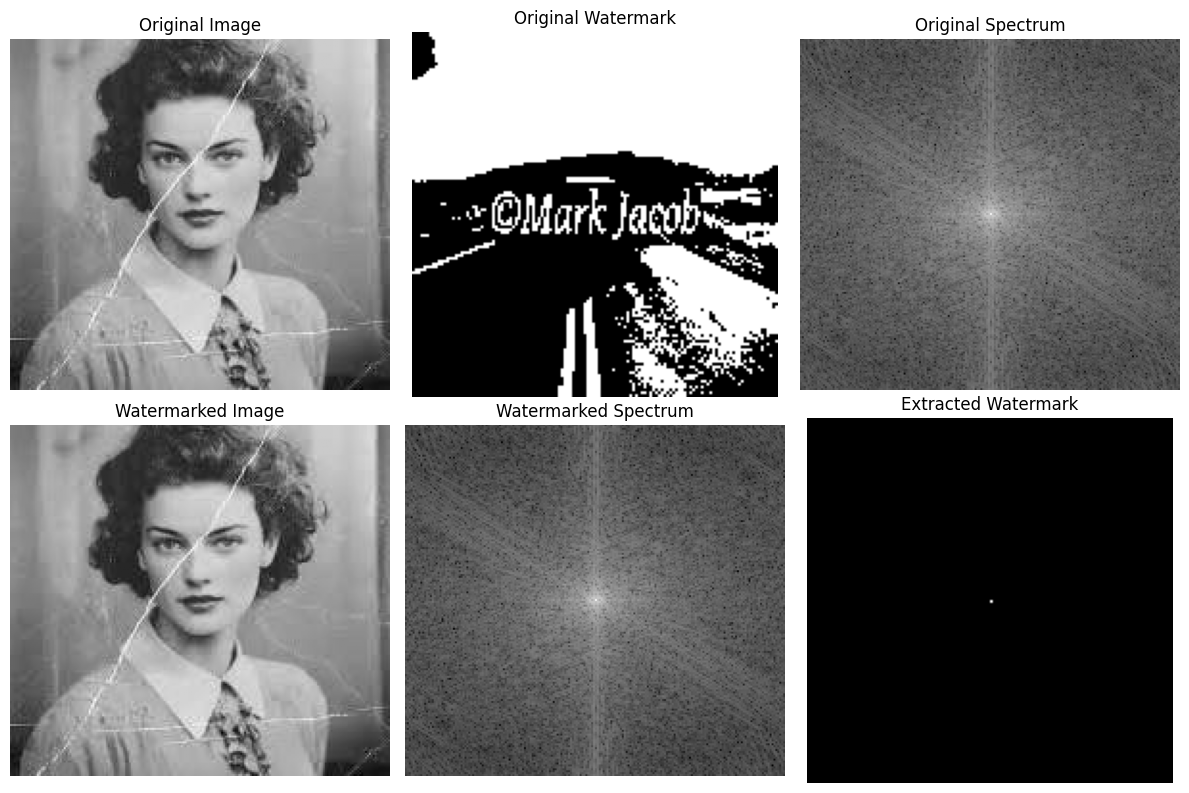

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# Load image
image = cv2.imread('/content/image.jpg', cv2.IMREAD_GRAYSCALE)
if image is None:
    print("Error: Image not found!")
    exit()
# Load watermark
watermark = cv2.imread('/content/watermark.jpg', cv2.IMREAD_GRAYSCALE)
if watermark is None:
    print("Error: Watermark not found!")
    exit()
# Resize watermark
watermark = cv2.resize(watermark, (128, 128))
# Convert watermark to binary
_, watermark = cv2.threshold(
    watermark, 127, 1, cv2.THRESH_BINARY
)
# STEP 1: Fourier Transform of Original Image
f = np.fft.fft2(image)
fshift = np.fft.fftshift(f)
rows, cols = image.shape
crow, ccol = rows // 2, cols // 2
# Starting position for watermark
start_row = crow - 64
start_col = ccol - 64
# Strength of watermark
alpha = 20
# Copy Fourier coefficients
watermarked_fshift = fshift.copy()
# Get magnitude and phase
magnitude = np.abs(watermarked_fshift)
phase = np.angle(watermarked_fshift)
# STEP 2: Embed Watermark in Frequency Domain
# Select frequency region
region = magnitude[
    start_row:start_row + 128,
    start_col:start_col + 128
]
# Add watermark to magnitude
region = region + alpha * watermark
# Put modified region back
magnitude[
    start_row:start_row + 128,
    start_col:start_col + 128
] = region
# Reconstruct Fourier coefficients
watermarked_fshift = (
    magnitude * np.exp(1j * phase)
)
# STEP 3: Inverse Fourier Transform
watermarked_image = np.fft.ifft2(
    np.fft.ifftshift(watermarked_fshift)
)
watermarked_image = np.abs(watermarked_image)
# Normalize image
watermarked_image = cv2.normalize(
    watermarked_image,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)
# STEP 4: Extract Watermark
wf = np.fft.fft2(watermarked_image)
wfshift = np.fft.fftshift(wf)
# Calculate magnitude
wmagnitude = np.abs(wfshift)
# Extract same frequency region
extracted_region = wmagnitude[
    start_row:start_row + 128,
    start_col:start_col + 128
]
# Normalize extracted region
extracted_region = cv2.normalize(
    extracted_region,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)
# Threshold extracted watermark
_, extracted_watermark = cv2.threshold(
    extracted_region,
    127,
    255,
    cv2.THRESH_BINARY
)
# STEP 5: Display Results
plt.figure(figsize=(12, 8))
plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(watermark, cmap='gray')
plt.title("Original Watermark")
plt.axis("off")
plt.subplot(2, 3, 3)
plt.imshow(
    np.log(1 + np.abs(fshift)),
    cmap='gray'
)
plt.title("Original Spectrum")
plt.axis("off")
plt.subplot(2, 3, 4)
plt.imshow(watermarked_image, cmap='gray')
plt.title("Watermarked Image")
plt.axis("off")
plt.subplot(2, 3, 5)
plt.imshow(
    np.log(1 + np.abs(wfshift)),
    cmap='gray'
)
plt.title("Watermarked Spectrum")
plt.axis("off")
plt.subplot(2, 3, 6)
plt.imshow(extracted_watermark, cmap='gray')
plt.title("Extracted Watermark")
plt.axis("off")
plt.tight_layout()
plt.show()

7. Build a band-pass / band-reject filter designer for isolating specific frequency ranges in a textured image.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, Dropdown
# 1. Load image
image = cv2.imread('/content/image.jpg', cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Error: Image not found!")
else:
    # FFT
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)

    # Magnitude spectrum
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)

    rows, cols = image.shape
    crow, ccol = rows // 2, cols // 2

    # Create frequency distance matrix
    y, x = np.ogrid[:rows, :cols]
    distance = np.sqrt((x - ccol)**2 + (y - crow)**2)
# 2. Filter Designer
def frequency_filter(filter_type='Band-Pass',
                     low_frequency=20,
                     high_frequency=80):

    # Create filter mask
    if filter_type == 'Band-Pass':
        mask = np.logical_and(
            distance >= low_frequency,
            distance <= high_frequency
        ).astype(np.float32)

    else:  # Band-Reject
        mask = np.logical_or(
            distance < low_frequency,
            distance > high_frequency
        ).astype(np.float32)

    # Apply filter
    filtered_fshift = fshift * mask

    # Inverse FFT
    filtered_image = np.fft.ifft2(
        np.fft.ifftshift(filtered_fshift)
    )

    filtered_image = np.abs(filtered_image)

    # Normalize for display
    filtered_image = cv2.normalize(
        filtered_image,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    # Filtered spectrum
    filtered_spectrum = 20 * np.log(
        np.abs(filtered_fshift) + 1
    )
    # Display
    plt.figure(figsize=(15, 8))

    plt.subplot(2, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(magnitude_spectrum, cmap='gray')
    plt.title("Original Frequency Spectrum")
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.imshow(mask, cmap='gray')
    plt.title(f"{filter_type} Filter Mask")
    plt.axis('off')

    plt.subplot(2, 3, 4)
    plt.imshow(filtered_spectrum, cmap='gray')
    plt.title("Filtered Frequency Spectrum")
    plt.axis('off')

    plt.subplot(2, 3, 5)
    plt.imshow(filtered_image, cmap='gray')
    plt.title("Filtered Image")
    plt.axis('off')

    plt.tight_layout()
    plt.show()
# 3. Interactive Controls
interact(
    frequency_filter,
    filter_type=Dropdown(
        options=['Band-Pass', 'Band-Reject'],
        value='Band-Pass',
        description='Filter:'
    ),
    low_frequency=IntSlider(
        min=1,
        max=200,
        step=1,
        value=20,
        description='Low:'
    ),
    high_frequency=IntSlider(
        min=2,
        max=300,
        step=1,
        value=80,
        description='High:'
    )
);

interactive(children=(Dropdown(description='Filter:', options=('Band-Pass', 'Band-Reject'), value='Band-Pass')…

8. Develop a demo that swaps the phase and magnitude components between two images to show their relative importance.

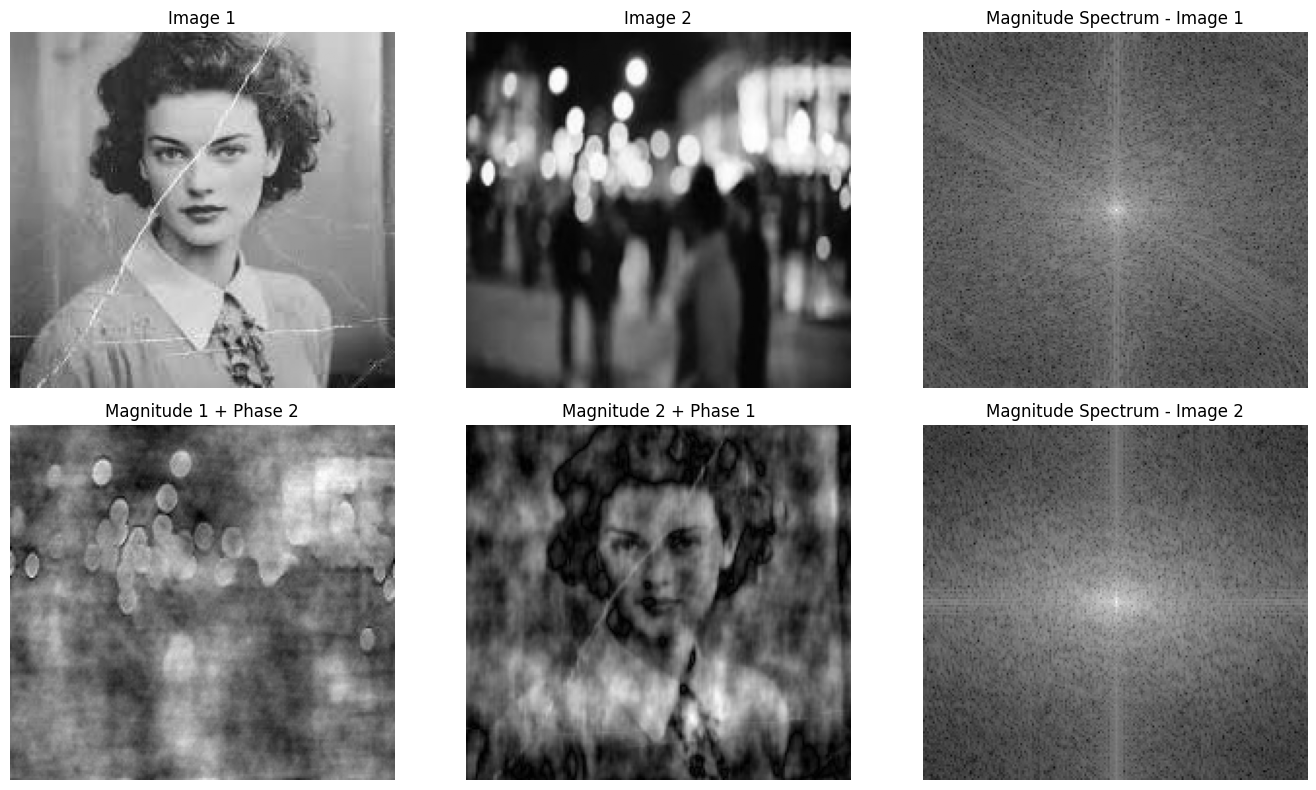

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# 1. Load two images
image1 = cv2.imread('/content/image.jpg', cv2.IMREAD_GRAYSCALE)
image2 = cv2.imread('/content/image2.jpg', cv2.IMREAD_GRAYSCALE)

if image1 is None or image2 is None:
    print("Error: One or both images were not found!")
else:

    # Make both images the same size
    image2 = cv2.resize(image2, (image1.shape[1], image1.shape[0]))
    # 2. Fourier Transform
    fft1 = np.fft.fft2(image1)
    fft2 = np.fft.fft2(image2)

    # Shift zero frequency to center
    fft1_shift = np.fft.fftshift(fft1)
    fft2_shift = np.fft.fftshift(fft2)
    # 3. Separate magnitude and phase
    magnitude1 = np.abs(fft1_shift)
    phase1 = np.angle(fft1_shift)

    magnitude2 = np.abs(fft2_shift)
    phase2 = np.angle(fft2_shift)
    # 4. Swap magnitude and phase
    # Magnitude of Image 1 + Phase of Image 2
    combined_1 = magnitude1 * np.exp(1j * phase2)
    # Magnitude of Image 2 + Phase of Image 1
    combined_2 = magnitude2 * np.exp(1j * phase1)
    # 5. Inverse Fourier Transform
    result1 = np.fft.ifft2(
        np.fft.ifftshift(combined_1)
    )

    result2 = np.fft.ifft2(
        np.fft.ifftshift(combined_2)
    )

    # Take magnitude of complex result
    result1 = np.abs(result1)
    result2 = np.abs(result2)

    # Normalize results
    result1 = cv2.normalize(
        result1, None, 0, 255, cv2.NORM_MINMAX
    ).astype(np.uint8)

    result2 = cv2.normalize(
        result2, None, 0, 255, cv2.NORM_MINMAX
    ).astype(np.uint8)
    # 6. Display results
    plt.figure(figsize=(14, 8))
    plt.subplot(2, 3, 1)
    plt.imshow(image1, cmap='gray')
    plt.title("Image 1")
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(image2, cmap='gray')
    plt.title("Image 2")
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.imshow(
        np.log1p(magnitude1),
        cmap='gray'
    )
    plt.title("Magnitude Spectrum - Image 1")
    plt.axis('off')

    plt.subplot(2, 3, 4)
    plt.imshow(
        result1,
        cmap='gray'
    )
    plt.title("Magnitude 1 + Phase 2")
    plt.axis('off')

    plt.subplot(2, 3, 5)
    plt.imshow(
        result2,
        cmap='gray'
    )
    plt.title("Magnitude 2 + Phase 1")
    plt.axis('off')

    plt.subplot(2, 3, 6)
    plt.imshow(
        np.log1p(magnitude2),
        cmap='gray'
    )
    plt.title("Magnitude Spectrum - Image 2")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

9. Create a blur-detection tool that flags blurry images based on the high-frequency energy content of their spectrum.

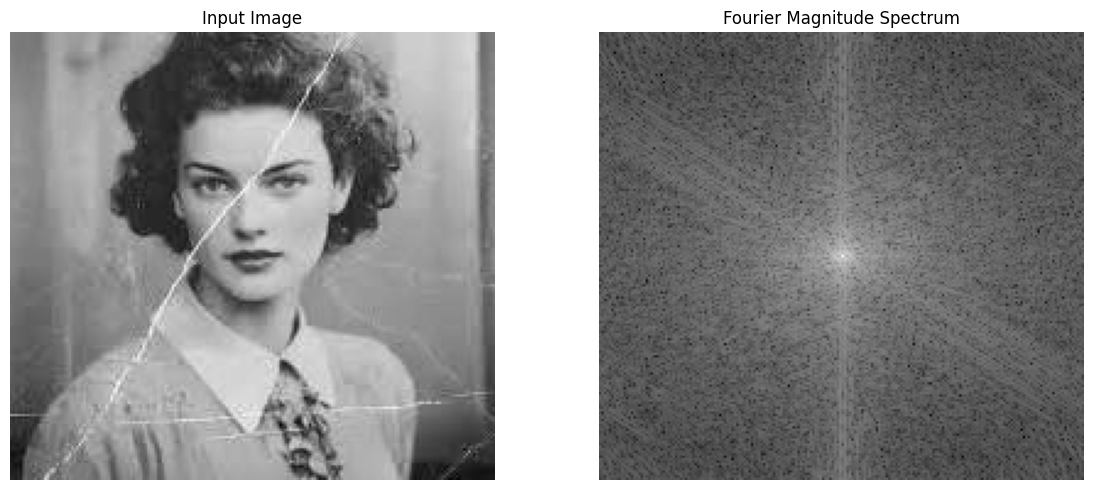

----------------------------------
Blur Detection Results
----------------------------------
High-Frequency Energy Ratio: 0.52 %
Threshold: 5.0 %
Result: BLURRY IMAGE


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# 1. Load image
image = cv2.imread('/content/image.jpg', cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Error: Image not found!")
else:
    # 2. Fourier Transform
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    # Magnitude spectrum
    magnitude = np.abs(fshift)
    # 3. Create frequency distance matrix
    rows, cols = image.shape
    crow, ccol = rows // 2, cols // 2

    y, x = np.ogrid[:rows, :cols]

    distance = np.sqrt(
        (x - ccol) ** 2 +
        (y - crow) ** 2
    )
    # 4. Select high-frequency region
    # The center contains low frequencies.
    # Outer region contains high frequencies.
    cutoff = min(rows, cols) * 0.15
    high_frequency_mask = distance > cutoff
    # 5. Calculate high-frequency energy
    high_frequency_energy = np.sum(
        magnitude[high_frequency_mask] ** 2
    )
    total_energy = np.sum(magnitude ** 2)
    # Percentage of energy in high frequencies
    high_frequency_ratio = (
        high_frequency_energy / total_energy
    ) * 100
    # 6. Blur decision
    # Adjust this threshold according to your images.
    threshold = 5.0

    if high_frequency_ratio < threshold:
        result = "BLURRY IMAGE"
    else:
        result = "SHARP IMAGE"
    # 7. Display results
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Input Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(
        np.log1p(magnitude),
        cmap='gray'
    )
    plt.title("Fourier Magnitude Spectrum")
    plt.axis('off')

    plt.tight_layout()
    plt.show()
    # 8. Print results
    print("----------------------------------")
    print("Blur Detection Results")
    print("----------------------------------")
    print("High-Frequency Energy Ratio:",
          round(high_frequency_ratio, 2), "%")
    print("Threshold:", threshold, "%")
    print("Result:", result)

10. Build a side-by-side visualizer comparing spatial-domain and frequency-domain filtering results for the same image.

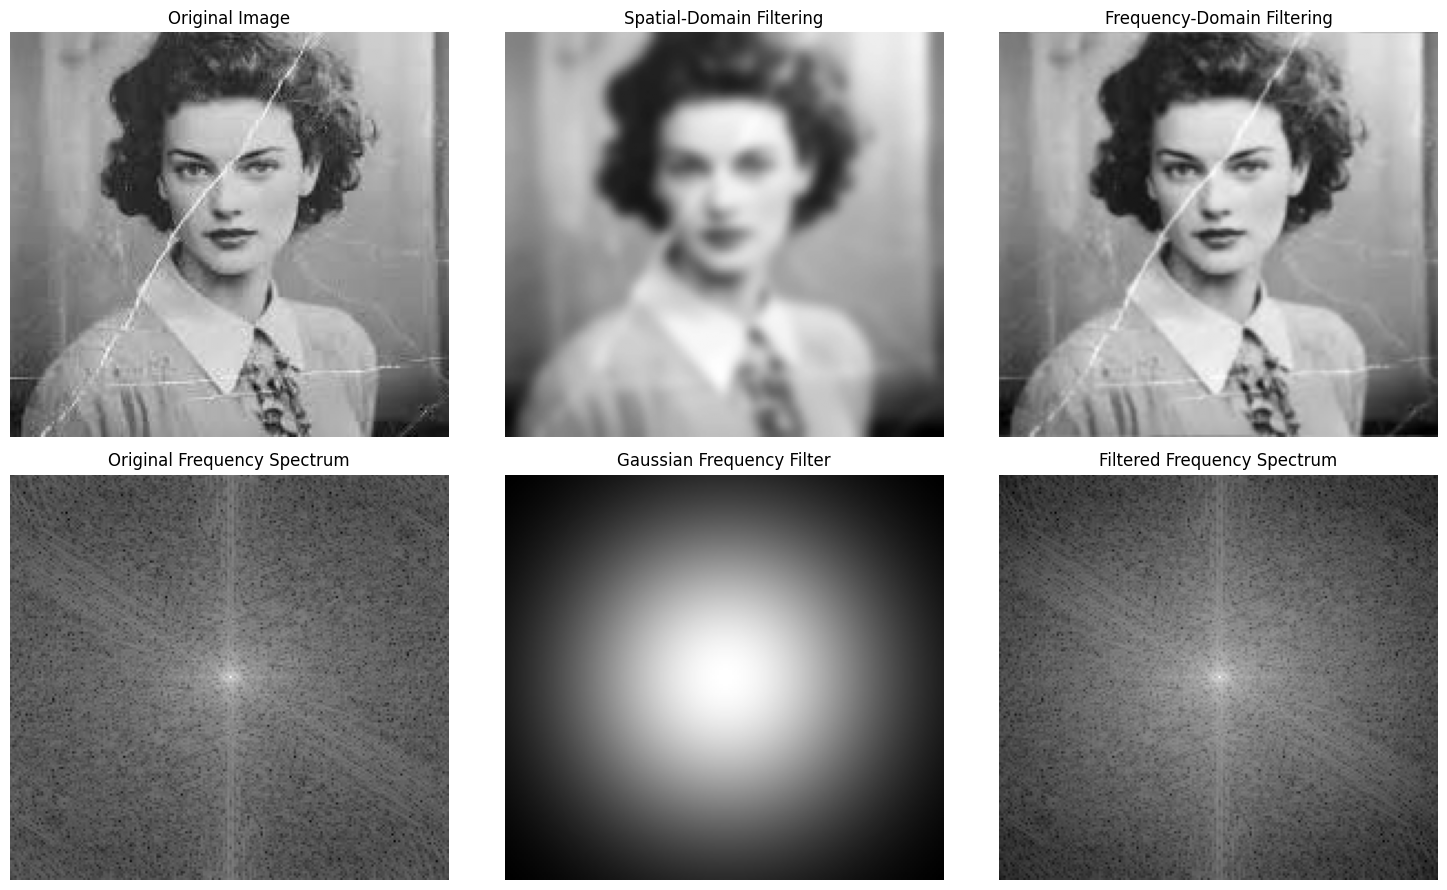

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# 1. Load image
image = cv2.imread('/content/image.jpg', cv2.IMREAD_GRAYSCALE)
if image is None:
    print("Error: Image not found!")
else:
    # 2. Spatial-domain filtering
    spatial_result = cv2.GaussianBlur(
        image,
        (15, 15),
        0
    )
    # 3. Fourier Transform
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    rows, cols = image.shape
    crow, ccol = rows // 2, cols // 2
    # 4. Create Gaussian Low-Pass Filter
    y, x = np.ogrid[:rows, :cols]
    distance_squared = (
        (x - ccol) ** 2 +
        (y - crow) ** 2
    )
    # Controls amount of frequency smoothing
    sigma = 50
    gaussian_filter = np.exp(
        -distance_squared / (2 * sigma ** 2)
    )
    # 5. Apply filter in frequency domain
    filtered_fshift = fshift * gaussian_filter
    # 6. Inverse Fourier Transform
    frequency_result = np.fft.ifft2(
        np.fft.ifftshift(filtered_fshift)
    )
    frequency_result = np.abs(frequency_result)

    frequency_result = cv2.normalize(
        frequency_result,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)
    # 7. Frequency spectrum
    original_spectrum = np.log(
        1 + np.abs(fshift)
    )
    filtered_spectrum = np.log(
        1 + np.abs(filtered_fshift)
    )
    # 8. Display comparison
    plt.figure(figsize=(15, 9))
    plt.subplot(2, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')
    plt.subplot(2, 3, 2)
    plt.imshow(spatial_result, cmap='gray')
    plt.title("Spatial-Domain Filtering")
    plt.axis('off')
    plt.subplot(2, 3, 3)
    plt.imshow(frequency_result, cmap='gray')
    plt.title("Frequency-Domain Filtering")
    plt.axis('off')
    plt.subplot(2, 3, 4)
    plt.imshow(original_spectrum, cmap='gray')
    plt.title("Original Frequency Spectrum")
    plt.axis('off')
    plt.subplot(2, 3, 5)
    plt.imshow(gaussian_filter, cmap='gray')
    plt.title("Gaussian Frequency Filter")
    plt.axis('off')
    plt.subplot(2, 3, 6)
    plt.imshow(filtered_spectrum, cmap='gray')
    plt.title("Filtered Frequency Spectrum")
    plt.axis('off')
    plt.tight_layout()
    plt.show()